# Solving the Heat Equation via Schrödingerisation with Classiq

This notebook demonstrates how to solve the one-dimensional heat equation using a quantum algorithm based on the Schrödingerisation technique.

The core idea is: convert a dissipative PDE into a Hamiltonian (Schrödinger-type) system that can be simulated unitarily on a quantum computer.

The heat equation governs how temperature diffuses through a medium over time. Because it is not time-reversible, it cannot be directly implemented as a unitary quantum circuit. Schrödingerisation lifts the problem into a higher-dimensional space where the dynamics become unitary, enabling quantum simulation.

The notebook is organized as follows:

1. Import dependencies and define utility functions.
2. Build the quantum building-block circuits (`Wj`, `V0`, controlled `V0`, `V_power`, `V_heat`).
3. Assemble the full quantum heat-equation solver, including classical reference solutions.
4. Run the solver and compare the quantum result against exact, matrix-exponential, and classical Schrödingerisation baselines.
5. Track the solution norm $\|u\|^2$ over time to verify energy decay.

## 1. Imports and Setup

This section loads the required libraries:

- **Classiq SDK** for quantum model construction, synthesis, and execution.
- **NumPy / SciPy** for classical linear algebra and sparse-matrix operations.
- **Matplotlib** for plotting results.

In [51]:
# Classiq imports
import cmath
import os
from gc import is_finalized
from time import time

import matplotlib.pyplot as plt
import numpy as np
import scipy.sparse as sp
from tqdm import tqdm

from classiq import *

## 2. Utility: Circuit Diagnostics

A helper function to inspect circuit metrics (width, depth, gate counts) for synthesised Classiq circuits.

In [52]:
def print_circuit_details(
    qc,
    qmod=True,
    max_width=None,
    optimization_parameter=OptimizationParameter.NO_OPTIMIZATION,
):
    if qmod:
        qprog = synthesize(
            main,
            constraints=Constraints(
                optimization_parameter=optimization_parameter, max_width=max_width
            ),
        )
        print(
            "Width =",
            qprog.data.width,
            ", Depth =",
            qprog.transpiled_circuit.depth,
            ", CX =",
            qprog.transpiled_circuit.count_ops["cx"],
        )
        show(qprog)
    else:
        t_qc = transpile(qc, basis_gates=["cx", "u"])
        print(f"depth = {t_qc.depth()}")
        print(f"width = {t_qc.width()}")
        print(f"ops = {t_qc.count_ops()}")

## 3. Building-Block Circuits

The quantum simulation of the heat equation is assembled from a hierarchy of parameterised sub-circuits. Each layer adds one level of structure:

| Circuit | Purpose |
|---------|---------|
| `Wj` | Core rotation: implements a controlled-`RZ` sandwiched between basis-change operations. |
| `V0` | One Hamiltonian-evolution step: composes `Wj` for $j = 1, \dots, n_x$ with a global phase. |
| `cV0` | Controlled version of `V0`, conditioned on an ancilla qubit. |
| `V_power` | Applies `cV0` raised to successive powers of two, controlled by each ancilla qubit — this is the key ingredient for the phase-estimation-like time encoding. |
| `V_heat` | A single heat-equation time step: `V_power` followed by an inverse `V0` correction. |

### 3.1 The $W_j$ Gate

For each index $j$, the gate $W_j(\theta, \lambda)$ acts on $j$ qubits as follows:

1. Apply a cascade of CNOTs from qubit $j{-}1$ down to qubit $0$.
2. Apply a phase gate $P(\lambda)$ and a Hadamard $H$ on qubit $j{-}1$.
3. Apply a multi-controlled $R_Z(\theta)$ targeting qubit $j{-}1$, controlled by all lower qubits.
4. Undo the Hadamard, phase, and CNOT cascade (within–apply pattern in Classiq).

This structure encodes the diagonal of the discretised Laplacian into quantum phases.

In [53]:
@qfunc
def Bj(j: int, lam: CReal, qbits: QArray[QBit]) -> None:
    H(qbits[j - 1])
    PHASE(-lam, qbits[j - 1])
    repeat(j - 1, lambda i: CX(qbits[j - 1], qbits[i]))


@qfunc
def my_mcrz(theta: CReal, num_qubits: int, qbits: QArray[QBit]) -> None:
    if num_qubits > 1:
        control(qbits[0 : num_qubits - 1], lambda: RZ(theta, qbits[num_qubits - 1]))
    else:
        RZ(theta, qbits[0])


@qfunc
def change_control_condition(num_qubits: int, xgate: CInt, qbits: QArray[QBit]):
    if_(xgate == 1, lambda: repeat(num_qubits - 1, lambda i: X(qbits[i])))

In [54]:
@qfunc
def Wj_circuit(
    j: int,
    theta: CReal,
    lam: CReal,
    xgate: CInt,
    qbits: QArray[QBit],
):
    within_apply(
        within=lambda: (
            invert(lambda: Bj(j=j, lam=lam, qbits=qbits)),
            change_control_condition(num_qubits=j, xgate=xgate, qbits=qbits),
        ),
        apply=lambda: my_mcrz(theta=theta, num_qubits=j, qbits=qbits),
    )


@qfunc
def main(qbits: Output[QArray[QBit]]) -> None:
    allocate(4, qbits)
    Wj_circuit(4, 0.1, 0.2, 0, qbits)

### 3.2 The $V_0$ Circuit

$V_0(\theta, n_x)$ applies a global phase $e^{i\theta}$ followed by the product

$$
V_0 = e^{i\theta} \prod_{j=1}^{n_x} W_j(\theta, 0),
$$

where $\theta = -2a \, \Delta t / (\Delta x)^2$ encodes the heat-equation time step. Here $a$ is the thermal diffusivity, $\Delta t$ the time-step size, and $\Delta x$ the spatial grid spacing.

This circuit is the building block for a single step of the Schrödingerised evolution.

In [55]:
@qfunc
def V0_circuit(theta: float, n: int, qbits: QArray[QBit]):
    phase(theta)
    for j in range(1, n + 1):
        Wj_circuit(j=j, theta=theta, lam=0, xgate=0, qbits=qbits[0:j])


@qfunc
def main(qbits: Output[QArray[QBit]]) -> None:
    allocate(4, qbits)
    V0_circuit(0.1, 4, qbits)

### 3.3 Controlled $V_0$

The controlled version $cV_0$ conditions the entire $V_0$ circuit on a single ancilla qubit. This is needed for the phase-kickback mechanism in the time-encoding step.

In Classiq, this is expressed directly with the `control` construct wrapping `V0_circuit`.

In [56]:
@qfunc
def cV0_circuit(theta: float, n: int, ctrl: QBit, qbits: QArray[QBit]) -> None:
    control(ctrl, lambda: V0_circuit(theta, n, qbits))


@qfunc
def main(ctrl: Output[QBit], qbits: Output[QArray[QBit]]) -> None:
    allocate(ctrl)
    allocate(4, qbits)
    cV0_circuit(0.1, 4, ctrl, qbits)

### 3.4 $V_{\text{power}}$: Binary Time Encoding

Given $n_a$ ancilla qubits, the circuit

$$
V_{\text{power}} = \prod_{j=0}^{n_a - 1} \bigl(cV_0\bigr)^{2^j},
$$

applies controlled-$V_0$ raised to powers of two. Each ancilla qubit $j$ controls $2^j$ repetitions of $cV_0$. This is analogous to the phase-estimation unitary powering and lets the ancilla register encode the momentum variable $p$ of the Schrödingerised system.

In [57]:
@qfunc
def V_power(
    na: CInt, nx: int, theta: float, qx: QArray[QBit], qp: QArray[QBit]
) -> None:
    repeat(na, lambda j: power(2**j, lambda: cV0_circuit(theta, nx, qp[j], qx)))


@qfunc
def main(qx: Output[QArray[QBit]], qp: Output[QArray[QBit]]) -> None:
    allocate(3, qp)
    allocate(4, qx)
    V_power(na=3, nx=4, theta=0.1, qx=qx, qp=qp)

### 3.5 $V_{\text{heat}}$: Single Heat Time Step

A complete heat-equation time step combines $V_{\text{power}}$ with a correction that removes the unconditional part of the evolution:

$$
V_{\text{heat}} = V_0^{-2^{n_a - 1}} \;\cdot\; V_{\text{power}}.
$$

Repeating $V_{\text{heat}}$ for $N_t$ steps advances the solution from $t = 0$ to $t = N_t \Delta t$.

In [58]:
@qfunc
def V_heat(na: CInt, nx: int, theta: float, qx: QArray[QBit], qp: QArray[QBit]) -> None:
    V_power(na=na, nx=nx, theta=theta, qx=qx, qp=qp)
    power(2 ** (na - 1), lambda: invert(lambda: V0_circuit(theta, nx, qx)))


@qfunc
def main(qx: Output[QArray[QBit]], qp: Output[QArray[QBit]]) -> None:
    allocate(3, qp)
    allocate(4, qx)
    V_heat(na=3, nx=4, theta=0.1, qx=qx, qp=qp)

In [59]:
## Multiple heat time steps - Classiq


@qfunc
def heat(
    Nt: CInt, na: CInt, nx: int, theta: float, qx: QArray[QBit], qp: QArray[QBit]
) -> None:
    power(Nt, lambda: V_heat(na=na, nx=nx, theta=theta, qx=qx, qp=qp))

## 4. Full Quantum Heat-Equation Solver

This section assembles the end-to-end solver. It includes:

- **Classical reference code** for validation:
  - `schro_classical` — solves the Schrödingerised system classically using sparse matrix exponentiation.
  - `matrix_exponential` — directly applies $e^{A t}$ to the initial condition.
  - `exact_heat` — evaluates the known analytical solution $u(x,t) = \sin(\pi x / L)\, e^{-a \pi^2 t / L^2}$.

- **Statevector parsing utilities** to extract the physical solution from the full quantum state, which lives in the joint $(x, p)$ Hilbert space.

- **The Classiq-based quantum solver** (`schro_classiq`), which synthesises, executes, and iterates the quantum circuits across multiple time steps.

In [60]:
# =========================
# Classical reference code
# =========================


def schro_classical(u0, A, R=4, na=3, T=3):
    A1, A2 = (A + A.T.conjugate()) / 2, -1j * (A - A.T.conjugate()) / 2
    Nx, Na = A1.shape[0], 2**na
    p = np.arange(-R * np.pi, R * np.pi, step=2 * R * np.pi / 2**na)
    fp, up = np.exp(-np.abs(p)), u0 * np.exp(-np.abs(p))[:, None]
    eta = np.arange(Na)
    eta[2 ** (na - 1) :] -= Na
    diag_eta = sp.csc_matrix((eta / R, (range(Na), range(Na))), shape=[Na, Na])
    ueta = np.fft.fft(up, axis=0).flatten()
    H = sp.csc_matrix(sp.kron(diag_eta, A1) + sp.kron(sp.eye(Na), A2))
    ueta = sp.linalg.expm_multiply(1j * H * T, ueta)
    return np.real(np.fft.ifft(ueta.reshape(Na, Nx), axis=0)[2 ** (na - 1)])


def matrix_exponential(u0, A, T=3):
    return sp.linalg.expm_multiply(A * T, u0)


def initial_heat(nx=4, L=2**4 + 1):
    dx = L / (2**nx + 1)
    x = np.arange(dx, L, step=dx)
    return x, np.sin(np.pi * x / L), dx


def exact_heat(x, L, T, a=1):
    return np.sin(np.pi * x / L) * np.exp(-a * np.pi**2 / L**2 * T)

### 4.2 Statevector Parsing Utilities

The quantum state lives in the tensor-product space of the spatial register ($n_x$ qubits) and the ancilla/momentum register ($n_a$ qubits). To recover the physical solution $u(x, t)$:

1. Read the full statevector from the Classiq execution result.
2. Reshape it into an $(N_a, N_x)$ matrix indexed by $(p, x)$.
3. Apply an inverse FFT along the $p$-axis to undo the QFT basis change.
4. Extract the row at $k^* = 2^{n_a - 1}$, which corresponds to $p = 0$.
5. Align the global phase so the result is real-valued.
6. Rescale by the product of the norms of $u_0$ and $f(p)$.

Helper functions also build projected observables for measuring $\|u\|^2$ without full state tomography, using Pauli decompositions that project onto the $p \geq 0$ subspace.

In [61]:
def get_magnitudes_phases(result) -> tuple[list[complex], list[complex]]:
    df = result.dataframe.copy()
    df = df.sort_values(by=["qp", "qx"]).reset_index(drop=True)
    magnitudes = [float(magnitude) for magnitude in df["magnitude"]]
    phases = [np.pi * float(str(phase)[:-1]) for phase in df["phase"]]
    return magnitudes, phases


def global_phase_align(u_slice):
    """
    Remove a global phase so the largest-magnitude component is real-positive.
    This fixes the 'u_slice is mostly imaginary' bug before taking np.real().
    """
    if u_slice is None or len(u_slice) == 0:
        return u_slice
    idx = int(np.argmax(np.abs(u_slice)))
    if np.abs(u_slice[idx]) > 0:
        u_slice = u_slice * np.exp(-1j * np.angle(u_slice[idx]))
    return u_slice


def identity_on_first_nx(nx: int):
    term = Pauli.I(0)
    for q in range(1, nx):
        term = term * Pauli.I(q)
    return term


def build_projected_observable_msb_last(nx: int, na: int, obs_term):
    msb = nx + na - 1
    rest = list(range(nx, nx + na - 1))  # all p qubits except msb

    # Start with one_op on msb as list of single-term ops
    terms = [0.5 * Pauli.I(msb), -0.5 * Pauli.Z(msb)]

    # Tensor with zero_op on each remaining p qubit, distributing into single terms
    for q in rest:
        new_terms = []
        for t in terms:
            new_terms.append(0.5 * (t * Pauli.I(q)))
            new_terms.append(0.5 * (t * Pauli.Z(q)))
        terms = new_terms

    # Multiply obs_term into EACH single term (safe)
    terms = [t * obs_term for t in terms]

    # Sum all terms (no int/float start)
    observable = terms[0]
    for t in terms[1:]:
        observable = observable + t

    return observable

### 4.3 Quantum Solver: `schro_classiq`

The main quantum solver performs the following loop:

```text
for each time step i = 1, …, Nt:
    1. If i == 1: prepare initial states (u₀, f(p)) via amplitude loading,
       then apply QFT basis change on the ancilla register.
       Else: reload the previous statevector via inplace_prepare_complex_amplitudes.
    2. Apply V_heat (one or more steps per circuit, controlled by time_steps_per_run).
    3. If final step or measuring observable: undo the basis change.
    4. Execute the circuit via Classiq's ExecutionSession and extract the new statevector
       for the next iteration.
```

Key parameters:

| Parameter | Meaning |
|-----------|---------|
| `na` | Number of ancilla (momentum) qubits. More qubits → better momentum resolution. |
| `nx` | Number of spatial qubits. Grid has $2^{n_x}$ points. |
| `R` | Momentum-space half-range: $p \in [-R\pi, R\pi)$. |
| `theta` | Time-step phase: $\theta = -2a \, \Delta t / (\Delta x)^2$. |
| `Nt` | Total number of time steps. |
| `time_steps_per_run` | How many `V_heat` applications to batch into a single circuit execution. |

In [67]:
def create_main(
    na: int,
    nx: int,
    R: int,
    theta: float,
    fp: list,
    u0: list,
    is_start: bool = False,
    magnitudes: CArray[CReal] = None,
    phases: list[float] = None,
    is_final: bool = False,
    time_steps_per_run: int = 1,
    obs=None,
):

    @qfunc
    def prepare_initial_states(qx: Output[QArray[nx]], qp: Output[QArray[na]]):
        fp_norm = fp / np.linalg.norm(fp)
        u0_norm = u0 / np.linalg.norm(u0)
        prepare_amplitudes(fp_norm.tolist(), 0, qp)
        prepare_amplitudes(u0_norm.tolist(), 0, qx)

    @qfunc
    def basis_change(qp: QArray[na]):
        qft(qp)
        X(qp[na - 1])

    @qfunc
    def invert_basis_change(qp: QArray[na]):
        invert(lambda: basis_change(qp))

    @qfunc
    def prepare_previous_states(qx: Output[QArray[nx]], qp: Output[QArray[na]]):
        temp = QArray()
        allocate(na + nx, temp)
        inplace_prepare_complex_amplitudes(magnitudes, phases, temp)
        bind(temp, [qx, qp])

    @qfunc
    def main(qx: Output[QNum[nx]], qp: Output[QNum[na]]) -> None:
        if is_start:
            prepare_initial_states(qx=qx, qp=qp)
            basis_change(qp=qp)
        else:
            prepare_previous_states(qx=qx, qp=qp)
            if obs is not None:
                basis_change(qp=qp)

        heat(time_steps_per_run, na, nx, theta / R, qx, qp)
        if obs is not None:
            invert_basis_change(qp=qp)

        if is_final and obs is None:
            invert_basis_change(qp=qp)

    return main


def schro_classiq(
    u0,
    theta,
    R=4,
    na=3,
    nx=4,
    Nt=1,
    return_parsed_sv=False,
    debug=False,
    obs=None,
    E=None,
    time_steps_per_run=1,
):
    dp = 2 * R * np.pi / 2**na
    p = np.arange(-R * np.pi, R * np.pi, step=2 * R * np.pi / 2**na)
    fp = np.exp(-np.abs(p))
    norm = np.linalg.norm(u0) * np.linalg.norm(fp)
    norm1 = np.linalg.norm(fp[2 ** (na - 1) :])  # norm of p>=0
    k_star = 2 ** (na - 1)

    # construct the observable
    if obs is not None:
        values = np.zeros((2, Nt))
        observable = build_projected_observable_msb_last(nx=nx, na=na, obs_term=obs)
    else:
        values = None

    backend_preferences = ClassiqBackendPreferences(
        backend_name="simulator_statevector"
    )
    exec_prefs = ExecutionPreferences(
        num_shots=1, backend_preferences=backend_preferences
    )
    prefs = Preferences(
        debug_mode=False,
        timeout_seconds=7200,
        optimization_timeout_seconds=600,
    )  #

    magnitudes = None
    phases = None
    Nt = Nt // time_steps_per_run
    print(f"New Nt is {Nt}")
    for i in range(Nt):
        print(f"\n=== Time step {i+1}/{Nt} ===")
        is_start = i == 0
        is_final = i == (Nt - 1)

        main_current_iteration = create_main(
            na=na,
            nx=nx,
            R=R,
            theta=theta,
            fp=fp,
            u0=u0,
            magnitudes=magnitudes,
            phases=phases,
            is_start=is_start,
            is_final=is_final,
            time_steps_per_run=time_steps_per_run,
            obs=obs,
        )

        start = time()
        qprog = synthesize(
            main_current_iteration,
            preferences=prefs,
            constraints=Constraints(max_width=na + nx),
        )

        if obs is not None:
            exec_prefs_1 = ExecutionPreferences(num_shots=10000)
            prefs = Preferences(
                debug_mode=False,
                timeout_seconds=7200,
                optimization_timeout_seconds=600,
            )
            # -------------------------
            # Session 1: projected EV p=0
            # -------------------------
            with ExecutionSession(qprog, execution_preferences=exec_prefs_1) as es1:
                print("Executing obs - estimate")
                ev_res = es1.observe(observable)
                ev = ev_res.value
                ev_real = float(np.real(ev))
                values[0, i] = ev_real * norm**2
                print(f"Execution time={np.round(time()-start)} seconds")

            # -------------------------
            # Session 2: probability p>=0
            # -------------------------
            exec_prefs_2 = ExecutionPreferences(
                num_shots=10000, backend_preferences=backend_preferences
            )
            msb = nx + na - 1
            with ExecutionSession(qprog, execution_preferences=exec_prefs_2) as es2:
                print("Executing obs - sample")
                res = es2.sample()

                df = res.dataframe

                # df -> MSB by threshold
                p_msb_thr_df = df.loc[df.qp >= k_star, "probability"].sum()

                print(p_msb_thr_df)

                values[1, i] = p_msb_thr_df * norm**2 / norm1**2
                magnitudes, phases = get_magnitudes_phases(res)
                print(f"Execution time={np.round(time()-start)} seconds")

        if is_start:
            pass
            # show(qprog)

        if is_final:
            # show(qprog)
            break

        if not obs:
            with ExecutionSession(qprog, execution_preferences=exec_prefs) as es:
                print("Executing")
                start = time()
                results = es.sample()
                print(f"Execution time={time()-start}")
                magnitudes, phases = get_magnitudes_phases(results)

    with ExecutionSession(qprog, execution_preferences=exec_prefs) as es:
        print("Executing")
        start = time()
        results = es.sample()
        print(f"Execution time={time()-start}")

    df = results.dataframe.sort_values("qx").reset_index(drop=True)
    state_result_1 = df[(df.qp == k_star)].amplitude.values
    u_slice = global_phase_align(state_result_1)
    u_raw = np.real(u_slice) * norm
    return u_raw, qprog, values

### 4.4 Orchestration: `run` and `plot_solution_single`

The `run` function ties everything together:

1. Sets up the spatial grid, initial condition, and finite-difference Laplacian $A$.
2. Computes $\theta$ from the physical parameters.
3. Runs all four solvers (quantum Classiq, classical Schrödinger, matrix exponential, exact) for comparison.
4. Returns the stacked solution matrix and (optionally) norm-tracking data.

`plot_solution_single` visualises the spatial solution $u(x, T)$ at the final time for a chosen ancilla size $n_a = 2k + 3$, overlaying all four methods on one plot.

`plot_norm` tracks $\|u(t)\|^2$ at every time step, comparing the quantum estimate (via projected observables) against the three classical baselines.

In [68]:
def run(na=5, R=4, T=1, dt=0.005, debug=False, measure=False, time_steps_per_run=-1):
    nx, L = 4, (2**4 + 1)
    a = L / np.pi**2

    Nt = int(T / dt)
    time_steps_per_run = Nt if time_steps_per_run == -1 else time_steps_per_run

    t = np.arange(dt, T + dt, step=dt)

    x, u0, dx = initial_heat(nx=nx, L=L)
    A = sp.csc_matrix(
        (-2 * np.eye(2**nx) + np.eye(2**nx, k=1) + np.eye(2**nx, k=-1)) * a / dx**2
    )
    theta, exact_fun = -2 * a / dx**2 * dt, exact_heat

    u_classical = schro_classical(u0=u0, A=A, R=R, na=na, T=Nt * dt)
    u_matrix = matrix_exponential(u0=u0, A=A, T=Nt * dt)
    u_exact = exact_fun(x=x, L=L, T=Nt * dt, a=a)

    if measure:
        # measure at each time step
        print("Running the classical simulation")
        obs = identity_on_first_nx(nx)
        values_classical, values_matrix, values_exact = (
            np.zeros(Nt),
            np.zeros(Nt),
            np.zeros(Nt),
        )

        for i in range(1, Nt + 1):
            u_classical = schro_classical(u0=u0, A=A, R=R, na=na, T=i * dt)
            u_matrix = matrix_exponential(u0=u0, A=A, T=i * dt)
            u_exact = exact_fun(x=x, L=L, T=i * dt, a=a)

            values_classical[i - 1] = np.linalg.norm(u_classical) ** 2
            values_matrix[i - 1] = np.linalg.norm(u_matrix) ** 2
            values_exact[i - 1] = np.linalg.norm(u_exact) ** 2
    else:
        # only check solutions at the final time
        obs, values_classical, values_matrix, values_exact = None, None, None, None
        u_classical = schro_classical(u0=u0, A=A, R=R, na=na, T=Nt * dt)
        u_matrix = matrix_exponential(u0=u0, A=A, T=Nt * dt)
        u_exact = exact_fun(x=x, L=L, T=Nt * dt, a=a)

    print("Running quantum simulation")

    u_raw, qprog, values_q = schro_classiq(
        u0,
        theta,
        R=R,
        nx=nx,
        na=na,
        Nt=Nt,
        debug=debug,
        obs=obs,
        E=values_classical,
        time_steps_per_run=1 if obs else time_steps_per_run,
    )

    # Stack results: [quantum_raw, classical_schro, matrix, exact]
    U = np.concatenate(
        (u_raw[None, :], u_classical[None, :], u_matrix[None, :], u_exact[None, :]),
        axis=0,
    )
    dist = np.linalg.norm(u_raw - u_classical)

    if measure:
        values = np.vstack(
            [
                values_q[0],  # 0: Proposed, p=0
                values_q[1],  # 1: Proposed, p>=0
                values_classical,  # 2: Classical Schro
                values_matrix,  # 3: Matrix operator
                values_exact,  # 4: Exact
            ]
        )
    else:
        values = None

    return (x, t, dt, na, T), qprog, U, values

## 5. Results: Solution at Final Time

The first experiment fixes $n_a = 3$ ancilla qubits, $T = 5$, $\Delta t = 0.5$ (so $N_t = 10$ steps, batched in groups of 2), and plots the spatial profile $u(x, T)$.

All four curves — quantum (Classiq), classical Schrödingerisation, matrix exponential, and exact — should agree closely, confirming that the quantum circuit correctly implements the heat-equation evolution.

In [69]:
def plot_solution_single(
    k=0,
    R=4,
    T=5,
    dt=0.5,
    ylim=(0, 1.2),
    debug=False,
    figsize=(8, 6),
    measure=False,
    time_steps_per_run=-1,
):
    fig, ax = plt.subplots(1, 1, figsize=figsize)

    na = k * 2 + 3
    # ========================
    # Run quantum program
    # ========================
    meta, qprog, U, _ = run(
        na=na,
        R=R,
        T=T,
        dt=dt,
        debug=debug,
        measure=measure,
        time_steps_per_run=time_steps_per_run,
    )
    # ========================
    x = meta[0]

    # U indices:
    # 0 = quantum raw
    # 1 = classical schro
    # 2 = matrix
    # 3 = exact
    q_quantum = U[0].copy()
    q_classic = U[1].copy()

    # sign-align quantum to classical schro (NOT exact)
    if float(np.dot(q_quantum, q_classic)) < 0:
        q_quantum = -q_quantum

    ax.plot(x, U[3], "red", label="Exact")
    ax.plot(x, U[2], "blue", linestyle="--", label="Matrix operator")
    ax.plot(
        x,
        U[1],
        color="black",
        linestyle="--",
        marker="s",
        label="Classical schro",
    )
    ax.plot(x, q_quantum, "d-", label=f"Quantum raw (dt={dt})")

    ax.set_xlabel("x")
    ax.set_ylim(list(ylim))
    ax.set_title(f"T = {T}    $n_p$ = {na}")

    ax.legend(prop={"size": 12})
    plt.tight_layout()
    plt.show()

In [70]:
def plot_norm(na=7, R=4, T=5, dt=0.005, debug=False):
    meta, qprog, U, values = run(na=na, R=R, T=T, dt=dt, debug=debug, measure=True)
    t = meta[1]

    plt.figure()
    plt.plot(t, values[4], "red")
    plt.plot(t, values[3], "blue", linestyle="--")
    plt.plot(t, values[2], "black")
    plt.plot(t, values[1], "mediumseagreen", linestyle="dotted")
    plt.plot(t, values[0], "orange", linestyle="dotted")

    plt.legend(
        [
            "Exact",
            "Matrix operator",
            f"Classical Schro, $n_p$={meta[3]}",
            f"Proposed, $n_p$={meta[3]}, $p\\geq0$",
            f"Proposed, $n_p$={meta[3]}, $p=0$",
        ]
    )
    plt.xlabel("T")
    plt.title(f"Heat, $\\|u\\|^2$")
    # plt.savefig(f"./-norm.pdf", dpi=600, format="pdf", bbox_inches="tight")
    plt.show()

Running quantum simulation
New Nt is 5

=== Time step 1/5 ===
Executing
Execution time=7.818274974822998

=== Time step 2/5 ===
Executing
Execution time=5.874553918838501

=== Time step 3/5 ===
Executing
Execution time=6.170758962631226

=== Time step 4/5 ===
Executing
Execution time=6.7596070766448975

=== Time step 5/5 ===
Executing
Execution time=6.6156980991363525


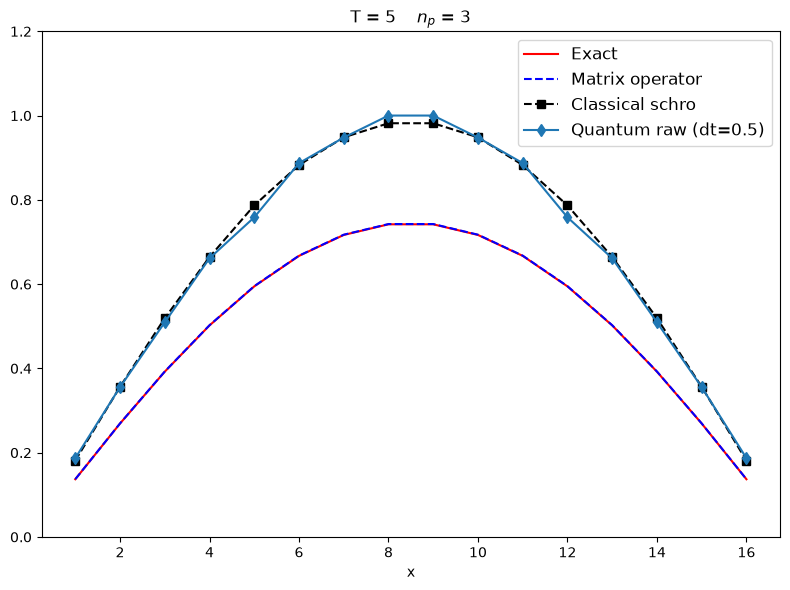

In [73]:
plot_solution_single(k=0, T=5, dt=0.5, ylim=[0, 1.2], debug=False, time_steps_per_run=2)

## 6. Results: Norm Decay Over Time

The second experiment uses $n_a = 5$, $T = 5$, $\Delta t = 0.05$ ($N_t = 100$ steps, one per circuit) and tracks the squared norm $\|u(t)\|^2$ at every time step.

For the heat equation, the norm decays exponentially:

$$
\|u(t)\|^2 = \|u_0\|^2 \, e^{-2a\pi^2 t / L^2}.
$$

The quantum estimate is obtained in two ways:

| Label | Method |
|-------|--------|
| Proposed, $p = 0$ | Projected expectation value at $p = 0$ only. |
| Proposed, $p \geq 0$ | Probability in the $p \geq 0$ subspace, rescaled by the weight norm. |

Both should track the classical curves, validating that the Schrödingerisation lift preserves the correct dissipative dynamics.

Running the classical simulation
Running quantum simulation
New Nt is 100

=== Time step 1/100 ===
Executing obs - estimate
Execution time=11.0 seconds
Executing obs - sample
0.8263560295577489
Execution time=16.0 seconds

=== Time step 2/100 ===
Executing obs - estimate
Execution time=35.0 seconds
Executing obs - sample
0.8244613087603726
Execution time=55.0 seconds

=== Time step 3/100 ===
Executing obs - estimate
Execution time=29.0 seconds
Executing obs - sample
0.8244705128107591
Execution time=44.0 seconds

=== Time step 4/100 ===
Executing obs - estimate
Execution time=27.0 seconds
Executing obs - sample
0.824459614504759
Execution time=51.0 seconds

=== Time step 5/100 ===
Executing obs - estimate
Execution time=29.0 seconds
Executing obs - sample
0.8244578979518922
Execution time=54.0 seconds

=== Time step 6/100 ===
Executing obs - estimate
Execution time=34.0 seconds
Executing obs - sample
0.8244563646156874
Execution time=56.0 seconds

=== Time step 7/100 ===
Executing obs 

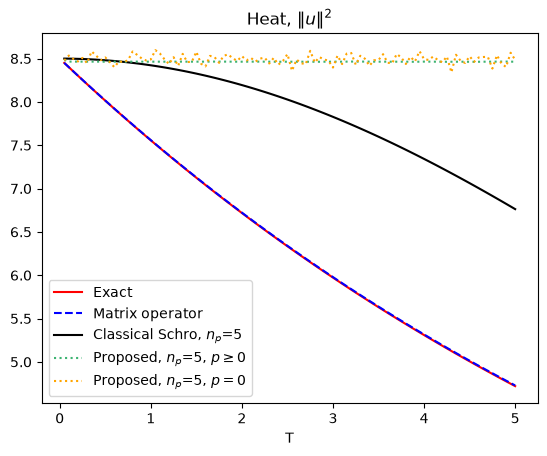

In [74]:
plot_norm(na=5, T=5, dt=0.05)